# Assignment: Image Segmentation with Different CNN Architectures

Train and compare at least two different CNN-based segmentation models (Simple FCN and a small U-Net-like model) on an image+mask dataset, and visualize their results.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
train_dataset_path = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/train2017"
mask_train_dataset_path = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data/COCO2017_SAMPLE/mask_train2017"
print("Image path exists:", os.path.exists(train_dataset_path))
print("Mask path exists:", os.path.exists(mask_train_dataset_path))

Image path exists: True
Mask path exists: True


In [34]:
import os

mask_list = os.listdir(mask_train_dataset_path)
print("Total masks:", len(mask_list))
print(mask_list[:20])


Total masks: 38102
['000000182706_mask.png', '000000182710_mask.png', '000000182715_mask.png', '000000182723_mask.png', '000000182728_mask.png', '000000182734_mask.png', '000000182736_mask.png', '000000182746_mask.png', '000000182755_mask.png', '000000182756_mask.png', '000000182758_mask.png', '000000182759_mask.png', '000000182765_mask.png', '000000182773_mask.png', '000000182775_mask.png', '000000182782_mask.png', '000000182784_mask.png', '000000182785_mask.png', '000000182793_mask.png', '000000182799_mask.png']


In [16]:
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, size=128, max_images=None):
        """
        img_dir   : path to images
        mask_dir  : path to masks
        size      : resize images/masks to (size, size)
        max_images: max number of images to load (for fast debugging)
        """
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.size = size

        # Build lookup for masks
        mask_files = os.listdir(mask_dir)
        self.mask_map = {}
        for m in mask_files:
            if "_mask" in m:
                key = m.replace("_mask.png", "").replace("_mask.jpg", "")
                self.mask_map[key] = m

        # Keep only images that have a matching mask
        self.files = []
        for f in sorted(os.listdir(img_dir)):
            key = f.split(".")[0]
            if key in self.mask_map:
                self.files.append(f)

        if max_images:
            self.files = self.files[:max_images]

        print("Total images in folder:", len(os.listdir(img_dir)))
        print("Images with masks:", len(self.files))
        print("Skipped (no mask):", len(os.listdir(img_dir)) - len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        key = img_name.split(".")[0]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, self.mask_map[key])

        # --- Load image ---
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))

        # --- Load mask ---
        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        # --- Convert to tensors ---
        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32) / 255.0
        mask = (mask > 127).astype('float32')   # convert to 0/1
        mask = torch.tensor(mask).unsqueeze(0)  # add channel dimension

        return img, mask




In [57]:
missing = []
for f in os.listdir(train_dataset_path):
    if not os.path.exists(os.path.join(mask_train_dataset_path, f)):
        missing.append(f)

print("Missing masks:", len(missing))
print(missing[:15])


Missing masks: 11828
['000000532933.jpg', '000000532989.jpg', '000000532735.jpg', '000000532732.jpg', '000000532976.jpg', '000000532967.jpg', '000000532877.jpg', '000000532779.jpg', '000000532623.jpg', '000000533011.jpg', '000000532780.jpg', '000000532540.jpg', '000000533316.jpg', '000000533158.jpg', '000000533477.jpg']


In [58]:
dataset = SegDataset(train_dataset_path, mask_train_dataset_path, size=128, max_images=200)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Dataset length:", len(dataset))

Total images in folder: 11828
Images with masks: 200
Skipped (no mask): 11628
Dataset length: 200


In [59]:
class SimpleFCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [ ]:
class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.mid = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

        self.final = nn.Sequential(
            nn.Conv2d(96, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        d = self.down(x)               # encoder
        p = self.pool(d)               # downsample
        m = self.mid(p)                # bottleneck
        u = self.up(m)                 # upsample
        c = torch.cat([u, d], dim=1)   # skip connection
        out = self.final(c)
        return out


In [61]:
def train_model(model, loader, epochs=3):
    model = model.to(device)
    optim = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.BCEWithLogitsLoss()

    for ep in range(epochs):
        total_loss = 0

        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = loss_fn(preds, masks)

            optim.zero_grad()
            loss.backward()
            optim.step()

            total_loss += loss.item()

        print(f"Epoch {ep+1}/{epochs} | Loss = {total_loss:.4f}")


In [62]:
fcn = SimpleFCN()
unet = SmallUNet()
print("Training FCN...")
train_model(fcn, loader, epochs=3)

print("Training U-Net...")
train_model(unet, loader, epochs=3)



Training FCN...
Epoch 1/3 | Loss = 30.0367
Epoch 2/3 | Loss = 29.4007
Epoch 3/3 | Loss = 29.2757
Training U-Net...
Epoch 1/3 | Loss = 31.3641
Epoch 2/3 | Loss = 29.8313
Epoch 3/3 | Loss = 29.4910


In [63]:
def show_preds(model, dataset, num=3):
    model.eval()
    for i in range(num):
        img, mask = dataset[i]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device))
            pred = torch.sigmoid(pred).cpu().squeeze().numpy()

        fig, ax = plt.subplots(1, 3, figsize=(12,4))
        ax[0].imshow(img.permute(1,2,0))
        ax[0].set_title("Image")
        ax[1].imshow(mask.squeeze(), cmap='gray')
        ax[1].set_title("Mask")
        ax[2].imshow(pred, cmap='gray')
        ax[2].set_title("Prediction")
        plt.show()


FCN Predictions:


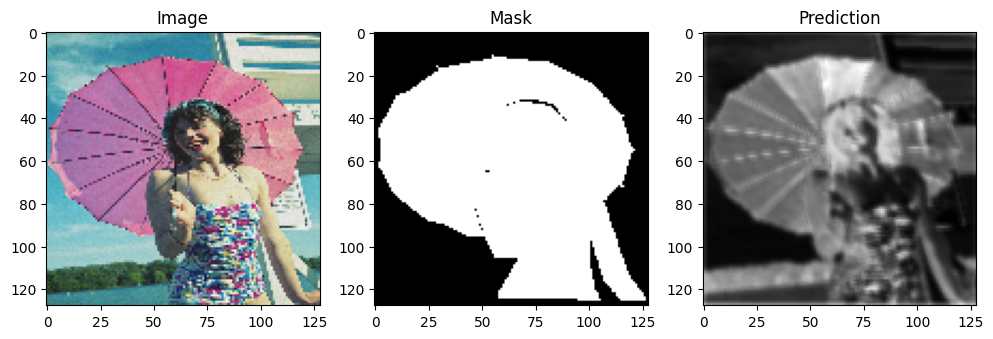

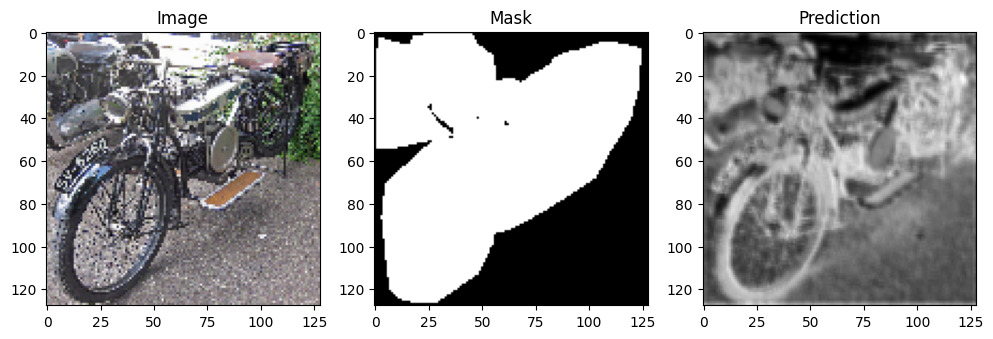

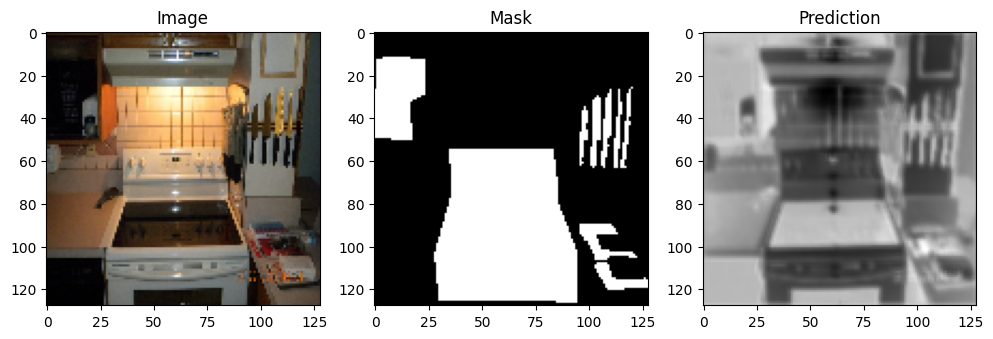

U-Net Predictions:


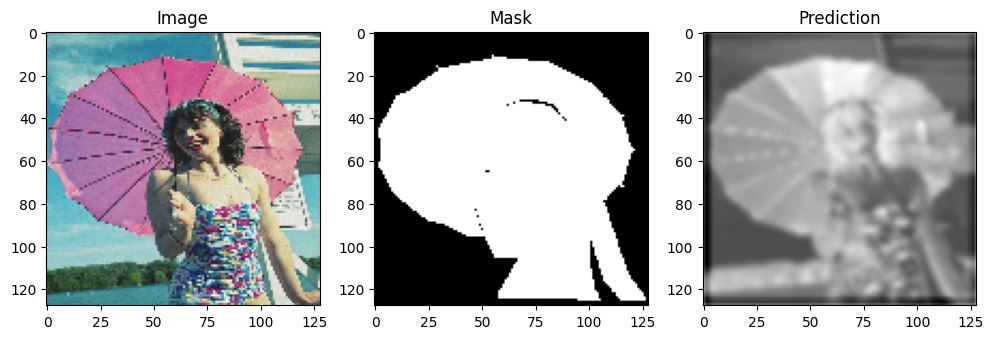

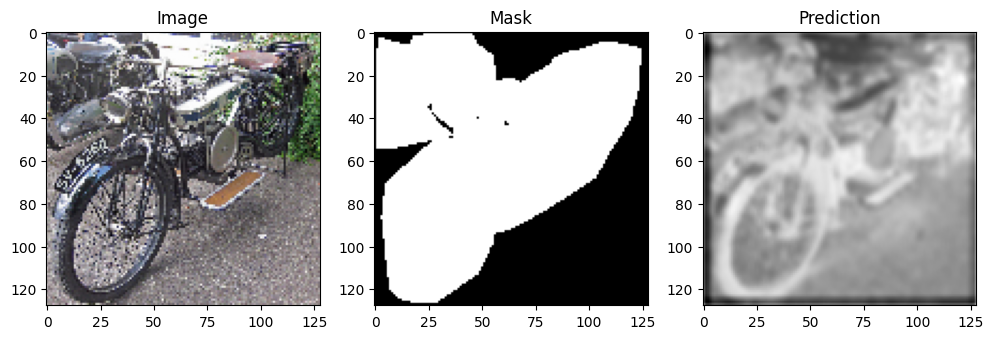

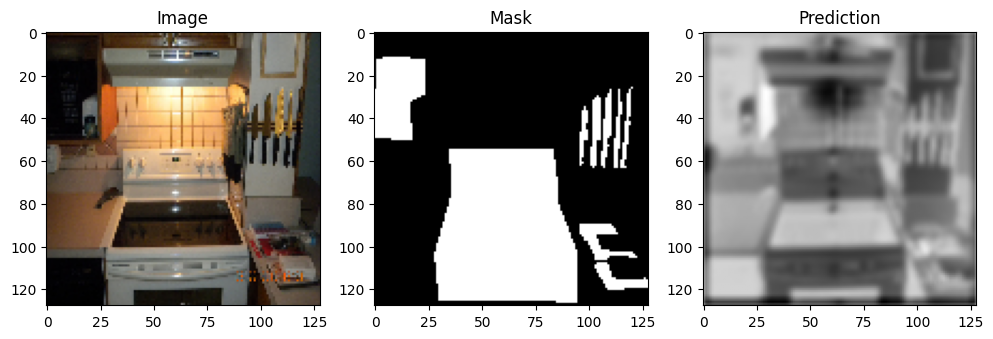

In [64]:
print("FCN Predictions:")
show_preds(fcn, dataset)

print("U-Net Predictions:")
show_preds(unet, dataset)

